<a href="https://colab.research.google.com/github/asnaraliya/ICT/blob/main/Unsupervised_learning_case_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score


In [13]:
# Load dataset
df = pd.read_csv("adult_dataset.csv")

# Quick look
print(df.shape)
df.head()


(48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [14]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Fill missing values
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

for col in df.select_dtypes(include=['int64','float64']).columns:
    df[col].fillna(df[col].median(), inplace=True)

# Encode categorical variables
categorical_cols = df.select_dtypes(include='object').columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Scale numerical features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_encoded)


/tmp/ipykernel_3671/2531886108.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_3671/2531886108.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

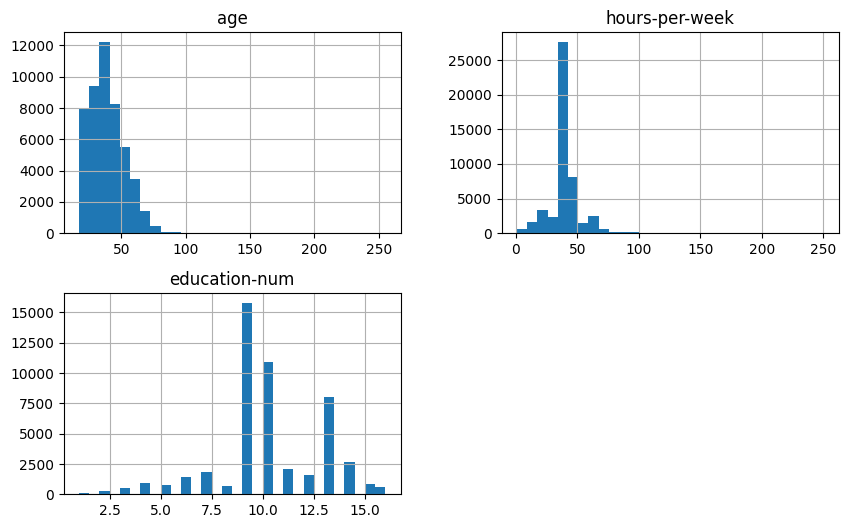

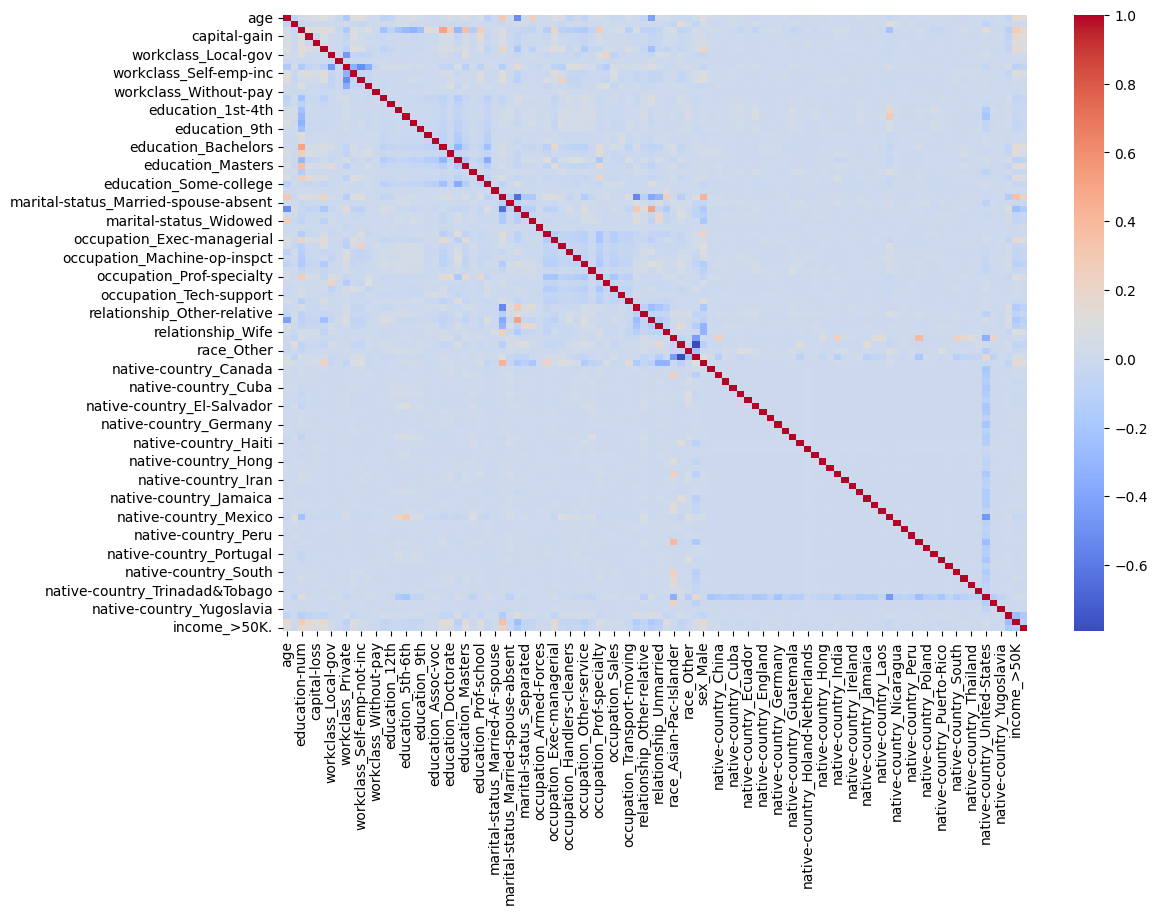

In [15]:
# Distribution plots
df[['age','hours-per-week','education-num']].hist(bins=30, figsize=(10,6))
plt.show()

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), cmap='coolwarm')
plt.show()


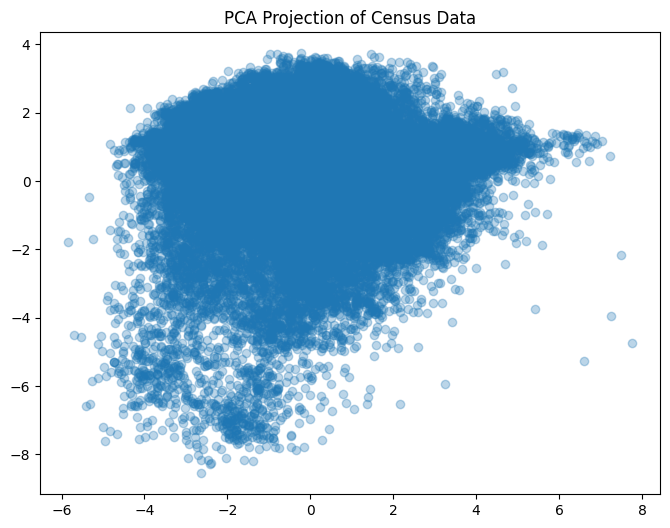

In [16]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)

plt.figure(figsize=(8,6))
plt.scatter(pca_result[:,0], pca_result[:,1], alpha=0.3)
plt.title("PCA Projection of Census Data")
plt.show()


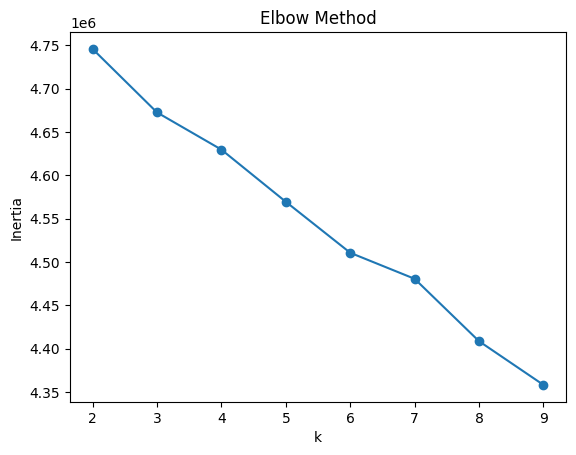

Silhouette Score: 0.04444034782876071


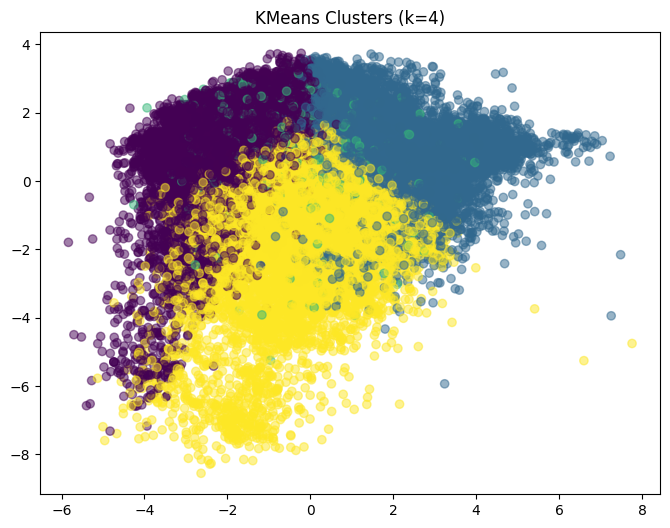

In [17]:
# KMeans with elbow method
inertia = []
for k in range(2,10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

# Choose k=4 (example)
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(df_scaled)

print("Silhouette Score:", silhouette_score(df_scaled, labels))

# Visualize clusters
plt.figure(figsize=(8,6))
plt.scatter(pca_result[:,0], pca_result[:,1], c=labels, cmap='viridis', alpha=0.5)
plt.title("KMeans Clusters (k=4)")
plt.show()


In [ ]:
df['Cluster'] = labels
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)
categorical_cols = ['workclass','education','marital-status','occupation',
                    'relationship','race','sex','native-country']

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df.groupby('Cluster')[col].value_counts(normalize=True))


               age         fnlwgt  education-num  capital-gain  capital-loss  \
Cluster                                                                        
0        27.741923  197088.587090       9.653418    154.963348     41.845233   
1        43.626480  185066.200818      13.036038   3576.033078    181.192375   
2        37.091829  191116.065799      10.952278    675.915401     94.091106   
3        43.852508  186678.847117       8.694811    401.106383     68.653124   

         hours-per-week  
Cluster                  
0             36.062512  
1             44.759923  
2             39.782357  
3             41.264658  

Column: workclass
Cluster  workclass       
0        Private             0.889912
         Local-gov           0.033625
         State-gov           0.027308
         Self-emp-not-inc    0.023755
         Federal-gov         0.016582
         Self-emp-inc        0.008028
         Never-worked        0.000461
         Without-pay         0.000329
1        Priva